In [3]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

import warnings
warnings.filterwarnings('ignore')


#pd.set_option('display.max_rows', )

In [4]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [5]:
print('訓練データのデータ数は{}、変数は{}種類です。'.format(df.shape[0], df.shape[1]))
print('テストデータのデータ数は{}、変数は{}種類です'.format(df_test.shape[0], df_test.shape[1]))

訓練データのデータ数は1460、変数は81種類です。
テストデータのデータ数は1459、変数は80種類です


In [6]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
for i in df:
    print(i,"\t",df[i].isnull().sum()/1460)


Id 	 0.0
MSSubClass 	 0.0
MSZoning 	 0.0
LotFrontage 	 0.1773972602739726
LotArea 	 0.0
Street 	 0.0
Alley 	 0.9376712328767123
LotShape 	 0.0
LandContour 	 0.0
Utilities 	 0.0
LotConfig 	 0.0
LandSlope 	 0.0
Neighborhood 	 0.0
Condition1 	 0.0
Condition2 	 0.0
BldgType 	 0.0
HouseStyle 	 0.0
OverallQual 	 0.0
OverallCond 	 0.0
YearBuilt 	 0.0
YearRemodAdd 	 0.0
RoofStyle 	 0.0
RoofMatl 	 0.0
Exterior1st 	 0.0
Exterior2nd 	 0.0
MasVnrType 	 0.5972602739726027
MasVnrArea 	 0.005479452054794521
ExterQual 	 0.0
ExterCond 	 0.0
Foundation 	 0.0
BsmtQual 	 0.025342465753424658
BsmtCond 	 0.025342465753424658
BsmtExposure 	 0.026027397260273973
BsmtFinType1 	 0.025342465753424658
BsmtFinSF1 	 0.0
BsmtFinType2 	 0.026027397260273973
BsmtFinSF2 	 0.0
BsmtUnfSF 	 0.0
TotalBsmtSF 	 0.0
Heating 	 0.0
HeatingQC 	 0.0
CentralAir 	 0.0
Electrical 	 0.0006849315068493151
1stFlrSF 	 0.0
2ndFlrSF 	 0.0
LowQualFinSF 	 0.0
GrLivArea 	 0.0
BsmtFullBath 	 0.0
BsmtHalfBath 	 0.0
FullBath 	 0.0
HalfBath 	 0.

In [9]:
for i in df_test:
    tmp = df_test[i].isnull().sum()/1460
    print(i,"\t",df_test[i].isnull().sum()/1460)

Id 	 0.0
MSSubClass 	 0.0
MSZoning 	 0.0027397260273972603
LotFrontage 	 0.15547945205479452
LotArea 	 0.0
Street 	 0.0
Alley 	 0.9260273972602739
LotShape 	 0.0
LandContour 	 0.0
Utilities 	 0.0013698630136986301
LotConfig 	 0.0
LandSlope 	 0.0
Neighborhood 	 0.0
Condition1 	 0.0
Condition2 	 0.0
BldgType 	 0.0
HouseStyle 	 0.0
OverallQual 	 0.0
OverallCond 	 0.0
YearBuilt 	 0.0
YearRemodAdd 	 0.0
RoofStyle 	 0.0
RoofMatl 	 0.0
Exterior1st 	 0.0006849315068493151
Exterior2nd 	 0.0006849315068493151
MasVnrType 	 0.6123287671232877
MasVnrArea 	 0.010273972602739725
ExterQual 	 0.0
ExterCond 	 0.0
Foundation 	 0.0
BsmtQual 	 0.030136986301369864
BsmtCond 	 0.030821917808219176
BsmtExposure 	 0.030136986301369864
BsmtFinType1 	 0.028767123287671233
BsmtFinSF1 	 0.0006849315068493151
BsmtFinType2 	 0.028767123287671233
BsmtFinSF2 	 0.0006849315068493151
BsmtUnfSF 	 0.0006849315068493151
TotalBsmtSF 	 0.0006849315068493151
Heating 	 0.0
HeatingQC 	 0.0
CentralAir 	 0.0
Electrical 	 0.0
1stF

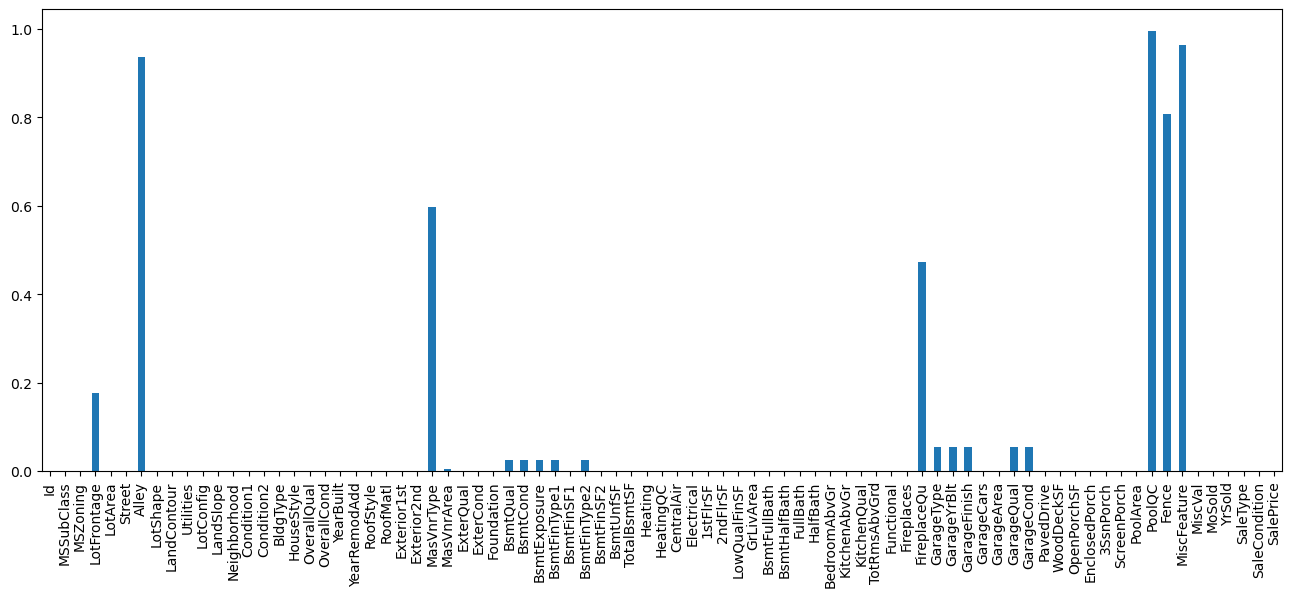

In [10]:
# 欠損率の計算
missing_ratio = df.isnull().sum() / len(df)

# グラフの大きさを指定
plt.figure(figsize=(16, 6))

# 欠損率のグラフを描画
missing_ratio.plot(kind='bar')

df_train = df.drop(missing_ratio[missing_ratio > 0].index, axis=1)

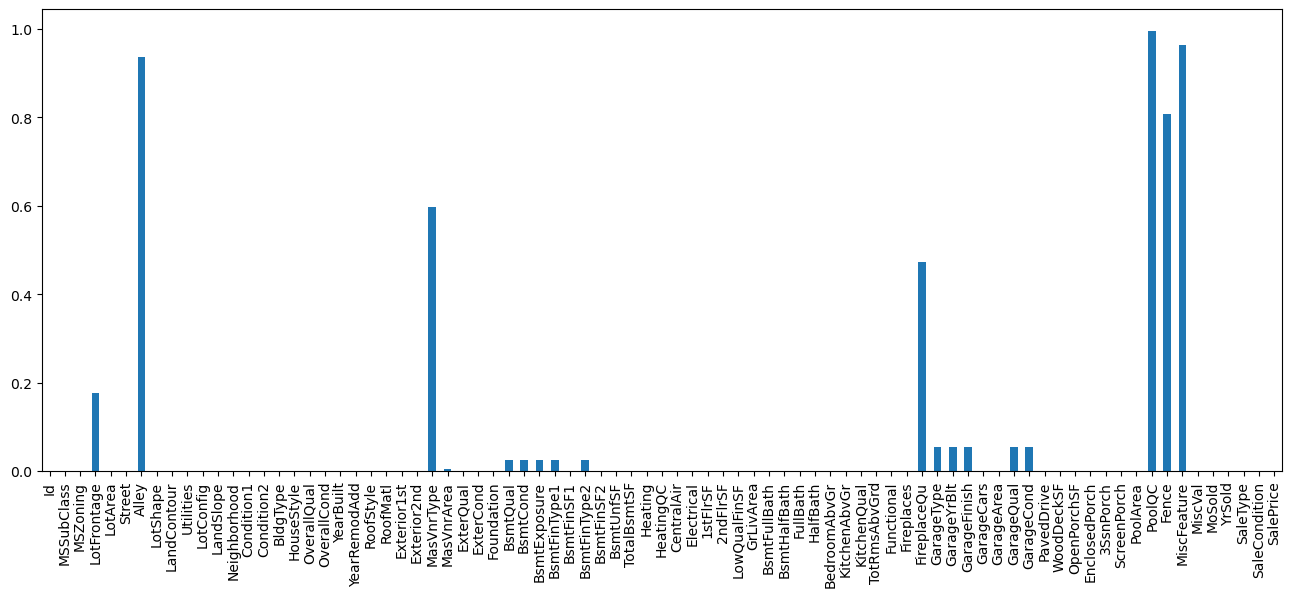

In [11]:
# 欠損率の計算
# missing_ratio = df_test.isnull().sum() / len(df)

# グラフの大きさを指定
plt.figure(figsize=(16, 6))

# 欠損率のグラフを描画
missing_ratio.plot(kind='bar')

df_test = df_test.drop(missing_ratio[missing_ratio > 0].index, axis=1)

In [12]:
df_train.describe(include=['object'])

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,ExterCond,Foundation,Heating,HeatingQC,CentralAir,KitchenQual,Functional,PavedDrive,SaleType,SaleCondition
count,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,...,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460
unique,5,2,4,4,2,5,3,25,9,8,...,5,6,6,5,2,4,7,3,9,6
top,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,TA,PConc,GasA,Ex,Y,TA,Typ,Y,WD,Normal
freq,1151,1454,925,1311,1459,1052,1382,225,1260,1445,...,1282,647,1428,741,1365,735,1360,1340,1267,1198


In [13]:
print(df_train.shape)
print(df_test.shape)

(1460, 62)
(1459, 61)


In [14]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns
# カテゴリカル変数を削除
df_train_c = df_train.drop(columns=categorical_columns)
df_test_c = df_test.drop(columns = categorical_columns)
df_test_c = df_test_c.drop(columns = ["Id"])

In [15]:
print(df_train_c.shape)
print(df_test_c.shape)

(1460, 35)
(1459, 33)


In [ ]:
df_y = df_train_c["SalePrice"]
df_x = df_train_c.drop(columns = ["SalePrice", "Id"])

In [17]:
model_lr = LinearRegression()
model_lr.fit(df_x, df_y)

LinearRegression()

In [19]:
reg = xgboost.XGBRegressor(#目的関数の指定 初期値も二乗誤差です
                       objective='reg:squarederror',
                       #学習のラウンド数 early_stoppingを利用するので多めに指定
                       n_estimators=50000,
                       #boosterに何を用いるか 初期値もgbtreeです
                       booster='gbtree',
                       #学習率
                       learning_rate=0.01,
                       #木の最大深さ
                       max_depth=6,
                       #シード値
                       random_state=2525)

In [21]:
reg.fit(df_x, df_y)

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50000, n_jobs=None,
             num_parallel_tree=None, random_state=2525, ...)

In [22]:
# すべての列を補完する場合
# この方法だと列名が消えてしまうので、元に戻してあげる必要があります
df_test_i = pd.DataFrame(imputer.fit_transform(df_test_c))
df_test_i.columns = df_test_c.columns

In [23]:
y_pred = model_lr.predict(df_test_i)
y_pred


predY = reg.predict(df_test_i)

In [24]:
print('Train Score: {}'.format(round(reg.score(df_x, df_y), 3)))

Train Score: 1.0


In [29]:
# 読み込むデータが格納されたディレクトリのパス，必要に応じて変更の必要あり
submission = pd.read_csv('sample_submission.csv')
submission.head(10)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
5,1466,177150.989247
6,1467,172070.659229
7,1468,175110.956520
8,1469,162011.698832
9,1470,160726.247831


In [31]:
submission['SalePrice'] = predY
submission.head(10)

,Id,SalePrice
0,1461,125725.640625
1,1462,156828.750000
2,1463,186485.562500
3,1464,186614.421875
4,1465,202297.265625
5,1466,173522.875000
6,1467,181653.250000
7,1468,169491.500000
8,1469,171931.250000
9,1470,116735.718750


In [35]:
submission.to_csv('submission.csv', index=False)